In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
data = np.load(r"D:\PENTING KUYLAH\output\1\data.npy")
earth_pos=np.load(r"D:\PENTING KUYLAH\output\1\earth_pos.npy")
moon_pos=np.load(r"D:\PENTING KUYLAH\output\1\moon_pos.npy")
print(data.shape)
print(earth_pos.shape)
print(moon_pos.shape)
data=(data*149_597_870.7)/1000
earth_pos=(earth_pos*149_597_870.7)/1000
moon_pos=(moon_pos*149_597_870.7)/1000


(87661, 2000, 3)
(87661, 3)
(87661, 3)


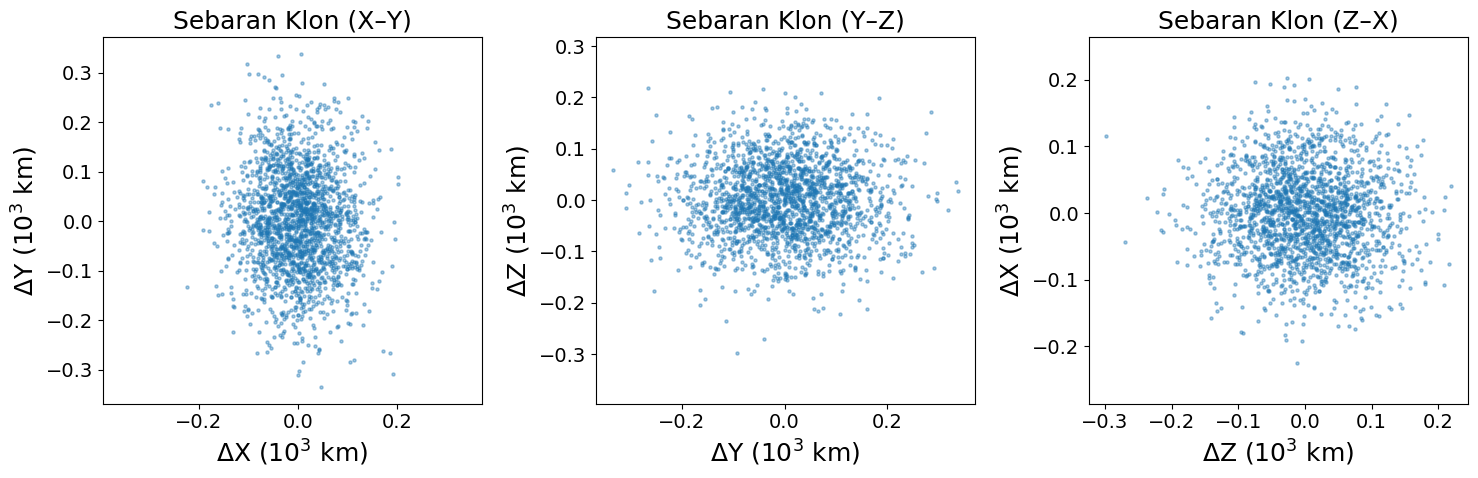

In [4]:
t0_data_pos=np.zeros((data.shape[1], 3))
for i in range (data.shape[1]):
    t0_data_pos[i,0]=data[0,i,0]
    t0_data_pos[i,1]=data[0,i,1]
    t0_data_pos[i,2]=data[0,i,2]

pairs = [
    (0, 1, r"ΔX ($10^{3}$ km)", r"ΔY ($10^{3}$ km)", "Sebaran Klon (X–Y)"),
    (1, 2, r"ΔY ($10^{3}$ km)", r"ΔZ ($10^{3}$ km)", "Sebaran Klon (Y–Z)"),
    (2, 0, r"ΔZ ($10^{3}$ km)", r"ΔX ($10^{3}$ km)", "Sebaran Klon (Z–X)")
]

plt.figure(figsize=(15,5))

for i, (ix, iy, xlabel, ylabel, title) in enumerate(pairs, start=1):
    x = t0_data_pos[:, ix]
    y = t0_data_pos[:, iy]

    x0 = x.mean()
    y0 = y.mean()

    plt.subplot(1, 3, i)
    plt.scatter(
        x - x0,
        y - y0,
        s=5,
        alpha=0.4
    )
    plt.xlabel(xlabel,fontsize=18)
    plt.ylabel(ylabel,fontsize=18)
    plt.title(title,fontsize=18)
    plt.axis("equal")

plt.tight_layout()
plt.savefig('persebaran_klon_t0.png', dpi=300, bbox_inches='tight')
plt.show()



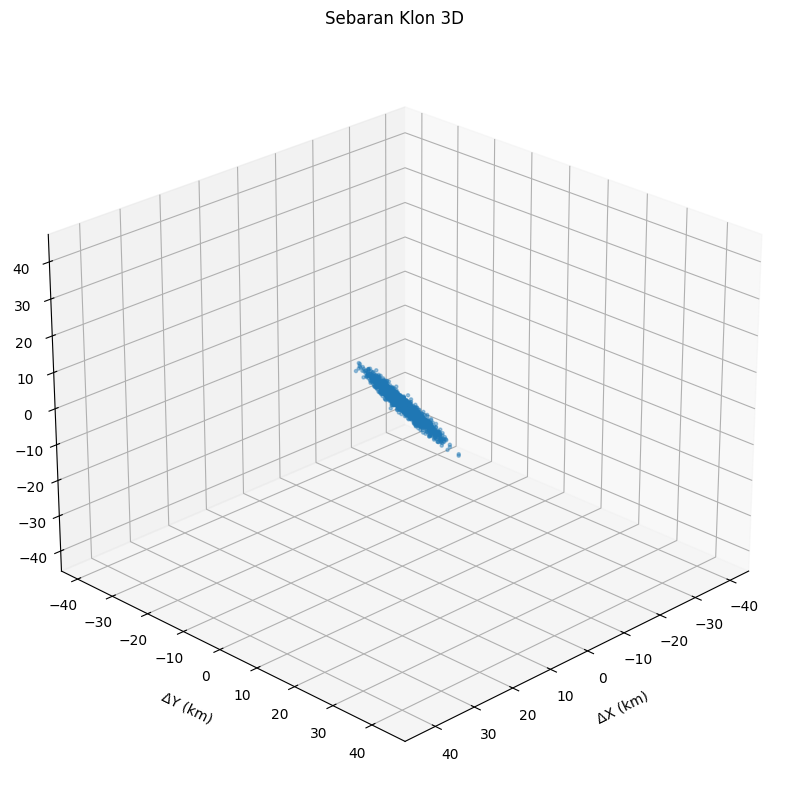

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================
# AMBIL TIMESTEP (misal t=0)
# =========================
t_idx = 40000

# Ambil posisi klon pada timestep tsb
t0_data_pos = data[t_idx]    # shape (2000,3)

# =========================
# AMBIL KOMPONEN X Y Z
# =========================
x = t0_data_pos[:, 0]
y = t0_data_pos[:, 1]
z = t0_data_pos[:, 2]

# =========================
# PUSATKAN KE MEAN
# =========================
x = x - x.mean()
y = y - y.mean()
z = z - z.mean()

# =========================
# BUAT FIGURE 3D
# =========================
fig = plt.figure(figsize=(9,8), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    x, y, z,
    s=5,
    alpha=0.4
)

ax.set_xlabel("ΔX (km)", labelpad=10)
ax.set_ylabel("ΔY (km)", labelpad=10)
ax.set_zlabel("ΔZ (km)", labelpad=15)

ax.set_title("Sebaran Klon 3D")

# =========================
# SAMAKAN SKALA X Y Z
# =========================
max_range = np.array([
    x.max()-x.min(),
    y.max()-y.min(),
    z.max()-z.min()
]).max() / 2

mid_x = (x.max()+x.min()) / 2
mid_y = (y.max()+y.min()) / 2
mid_z = (z.max()+z.min()) / 2

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

# Sudut pandang enak
ax.view_init(elev=25, azim=45)

plt.show()


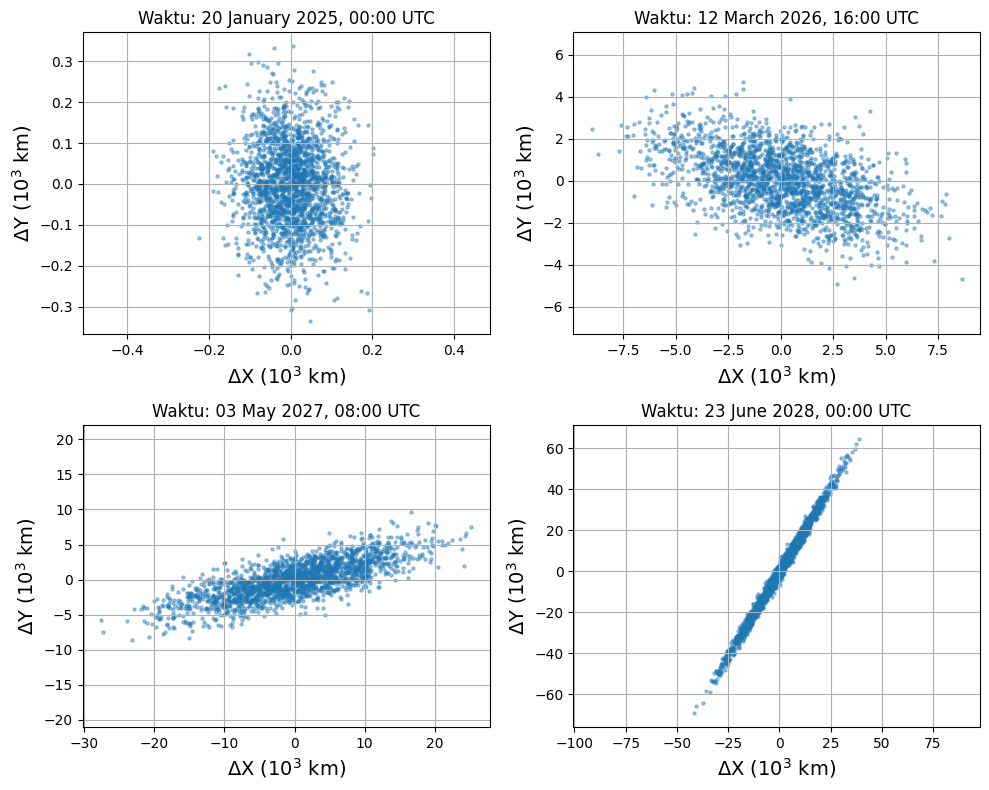

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone

# waktu awal dalam UTC
t0 = datetime(2025, 1, 20, 0, 0, tzinfo=timezone.utc)

# pilih 4 timestep (dalam jam)
timesteps = [0, 10000, 20000, 30000]

# 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, t_idx in enumerate(timesteps):

    pos = data[t_idx]

    x = pos[:, 0]
    y = pos[:, 1]

    # mean-center
    x = x - x.mean()
    y = y - y.mean()

    axes[i].scatter(
        x,
        y,
        s=5,
        alpha=0.4
    )

    # hitung waktu aktual UTC
    current_time = t0 + timedelta(hours=int(t_idx))

    # format waktu UTC
    waktu_str = current_time.strftime("%d %B %Y, %H:%M UTC")

    axes[i].set_title(f"Waktu: {waktu_str}")
    axes[i].set_xlabel("ΔX ($10^{3}$ km)",fontsize=14)
    axes[i].set_ylabel("ΔY ($10^{3}$ km)",fontsize=14)
    axes[i].axis("equal")
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('perubahan_persebaran_klon.png', dpi=300)
plt.show()

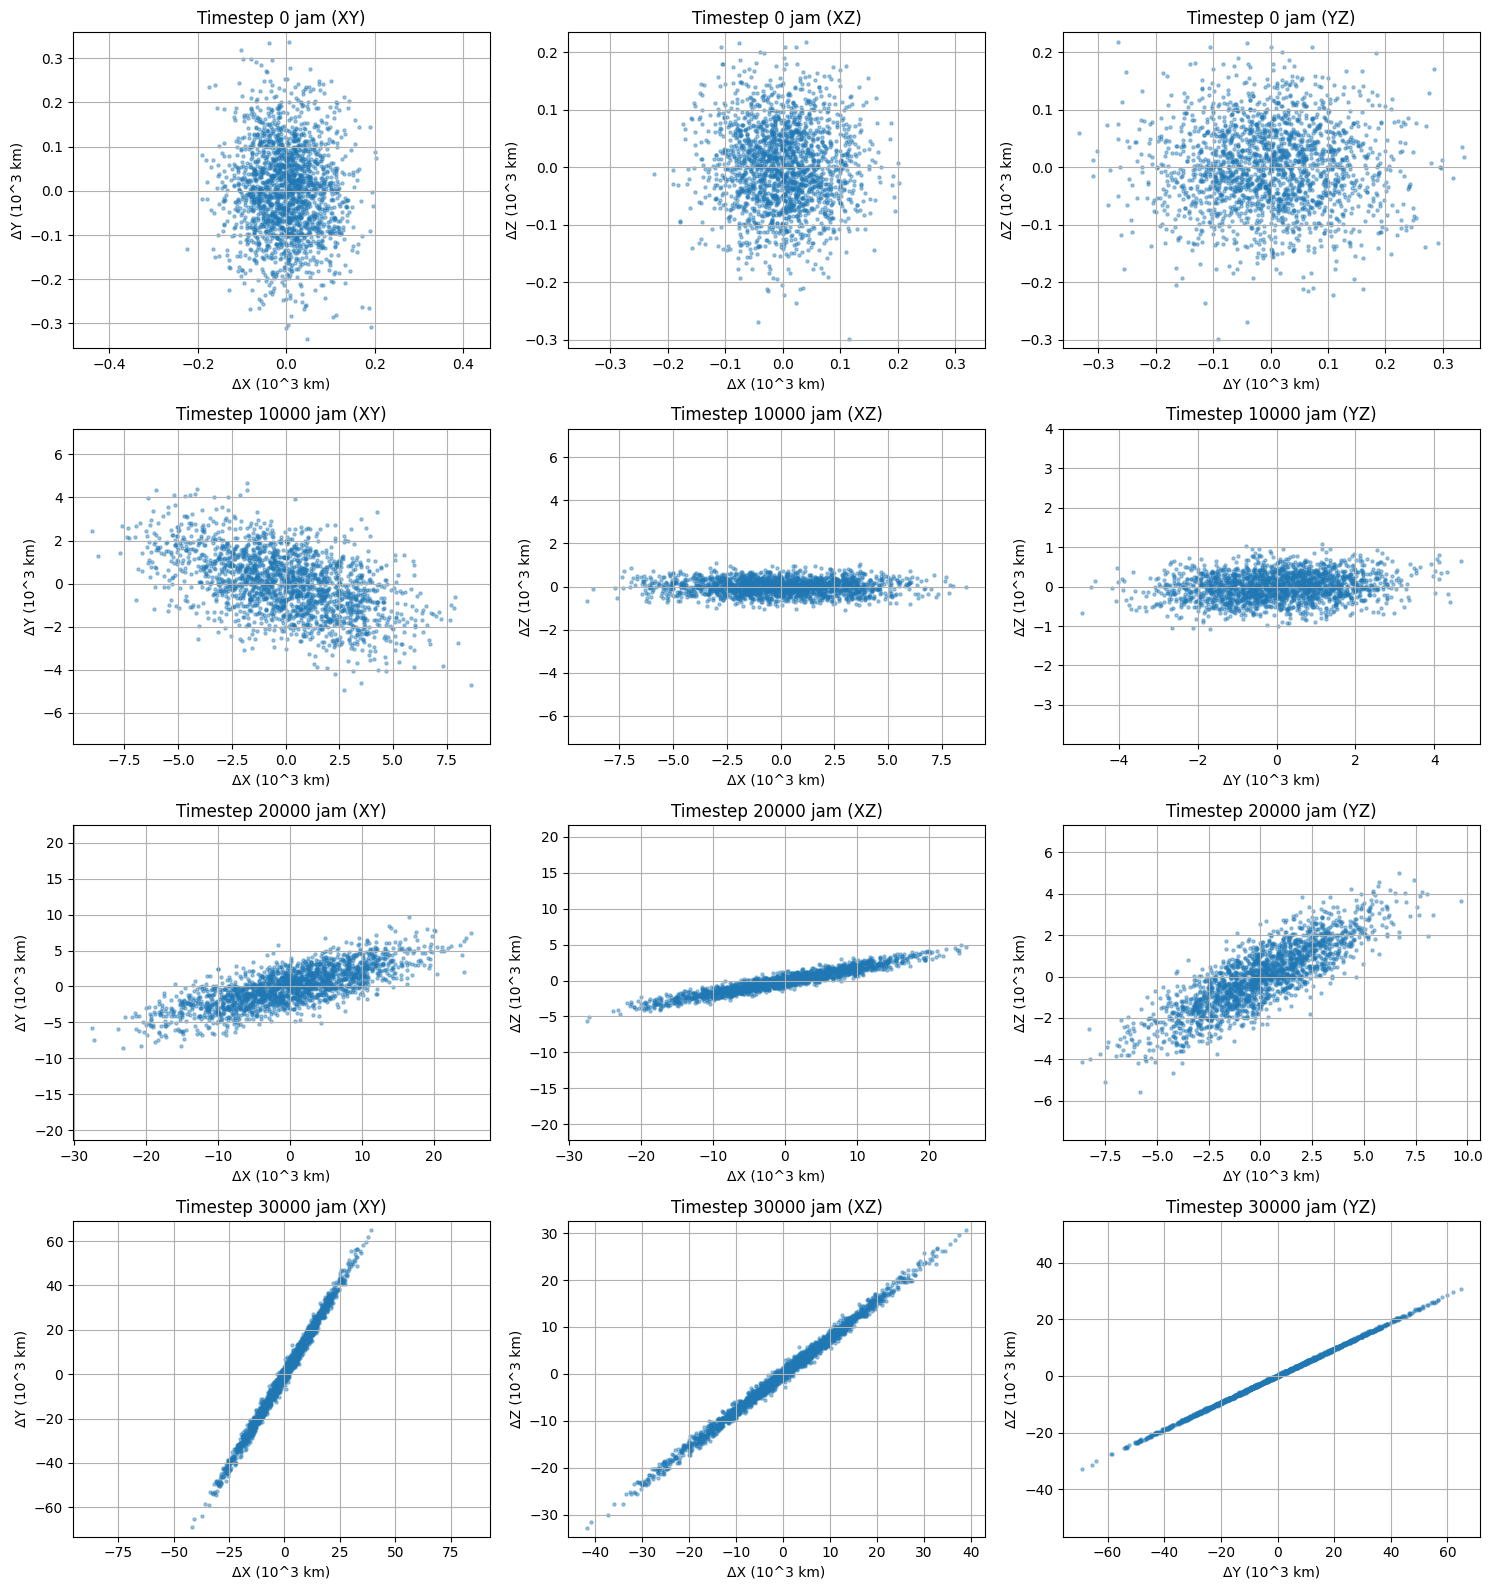

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# pilih 4 timestep
timesteps = [0, 10000, 20000, 30000]

# buat 4 baris (timestep) x 3 kolom (kombinasi sumbu)
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for row, t_idx in enumerate(timesteps):

    pos = data[t_idx]

    x = pos[:, 0]
    y = pos[:, 1]
    z = pos[:, 2]

    # mean-center
    x = x - x.mean()
    y = y - y.mean()
    z = z - z.mean()

    # --- Kolom 1: X-Y ---
    axes[row, 0].scatter(x, y, s=5, alpha=0.4)
    axes[row, 0].set_xlabel("ΔX (10^3 km)")
    axes[row, 0].set_ylabel("ΔY (10^3 km)")
    axes[row, 0].set_title(f"Timestep {t_idx} jam (XY)")
    axes[row, 0].axis("equal")
    axes[row, 0].grid(True)

    # --- Kolom 2: X-Z ---
    axes[row, 1].scatter(x, z, s=5, alpha=0.4)
    axes[row, 1].set_xlabel("ΔX (10^3 km)")
    axes[row, 1].set_ylabel("ΔZ (10^3 km)")
    axes[row, 1].set_title(f"Timestep {t_idx} jam (XZ)")
    axes[row, 1].axis("equal")
    axes[row, 1].grid(True)

    # --- Kolom 3: Y-Z ---
    axes[row, 2].scatter(y, z, s=5, alpha=0.4)
    axes[row, 2].set_xlabel("ΔY (10^3 km)")
    axes[row, 2].set_ylabel("ΔZ (10^3 km)")
    axes[row, 2].set_title(f"Timestep {t_idx} jam (YZ)")
    axes[row, 2].axis("equal")
    axes[row, 2].grid(True)

plt.tight_layout()
plt.show()

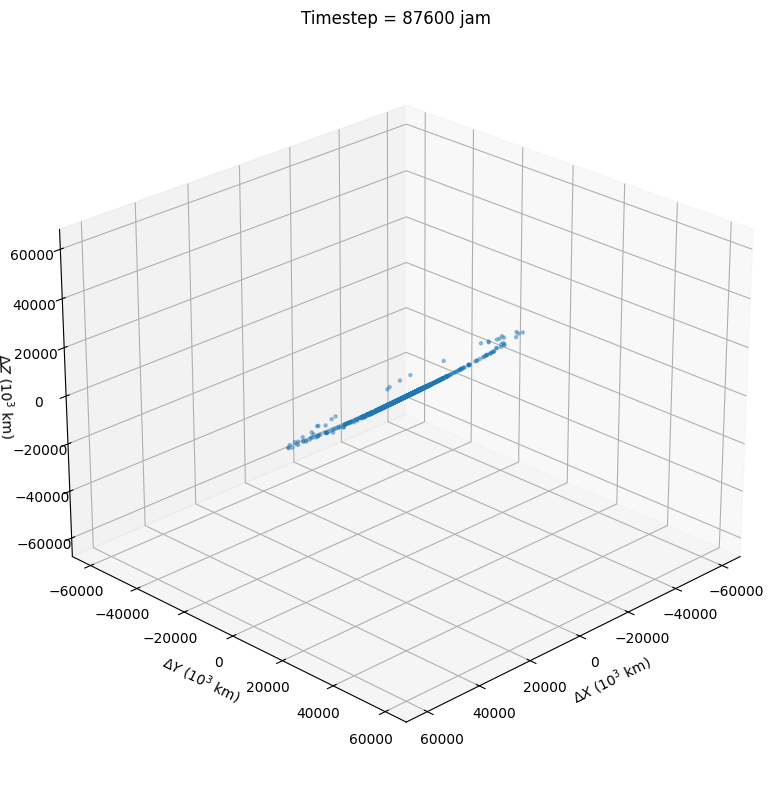

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter([], [], [], s=5, alpha=0.4)

ax.set_xlabel(r"$\Delta X$ ($10^{3}$ km)")
ax.set_ylabel(r"$\Delta Y$ ($10^{3}$ km)")
ax.set_zlabel(r"$\Delta Z$ ($10^{3}$ km)")

ax.grid(True)

def init():
    sc._offsets3d = ([], [], [])
    return sc,

def update(frame):

    pos = data[frame]

    # Pusatkan ke centroid
    x = pos[:, 0] - pos[:, 0].mean()
    y = pos[:, 1] - pos[:, 1].mean()
    z = pos[:, 2] - pos[:, 2].mean()

    sc._offsets3d = (x, y, z)

    # Autoscale dinamis
    max_range = max(
        np.abs(x).max(),
        np.abs(y).max(),
        np.abs(z).max()
    )
    margin = max_range * 0.1

    ax.set_xlim(-max_range - margin, max_range + margin)
    ax.set_ylim(-max_range - margin, max_range + margin)
    ax.set_zlim(-max_range - margin, max_range + margin)

    ax.view_init(elev=25, azim=45)

    ax.set_title(f"Timestep = {frame} jam")

    return sc,

ani = FuncAnimation(
    fig,
    update,
    frames=range(0, len(data), 200),
    init_func=init,
    blit=False
)

ani.save("orbit_3D_centroid.gif", writer=PillowWriter(fps=8))

plt.tight_layout()
plt.show()

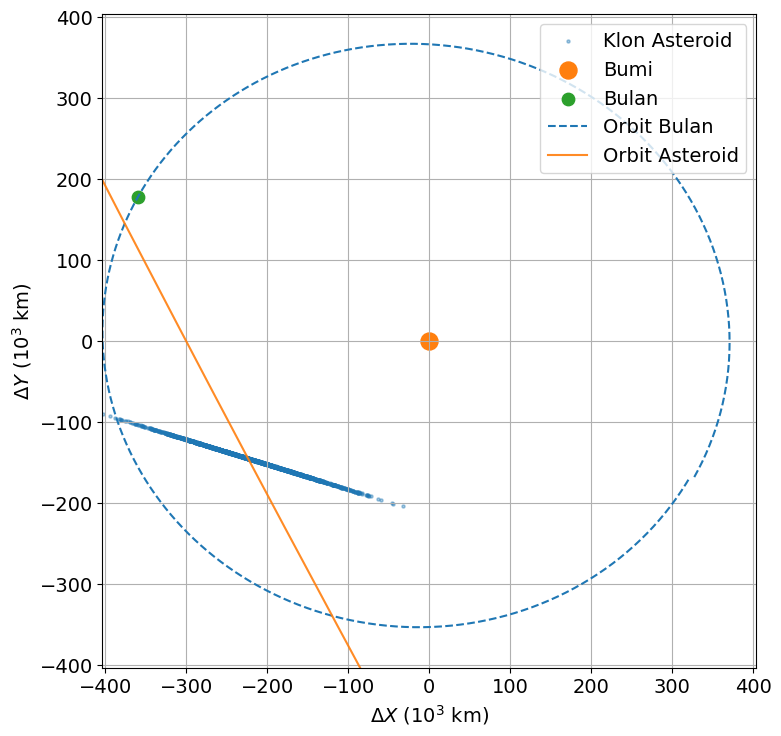

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
f_size=14
# samakan ukuran font
plt.rcParams.update({
    "font.size": f_size,
    "axes.titlesize": f_size,
    "axes.labelsize": f_size,
    "xtick.labelsize": f_size,
    "ytick.labelsize": f_size,
    "legend.fontsize": f_size
})

# waktu awal dalam UTC
t0 = datetime(2025, 1, 20, 0, 0, tzinfo=timezone.utc)

t_idx = 69440  # dalam jam

# hitung waktu aktual UTC
current_time = t0 + timedelta(hours=int(t_idx))
waktu_str = current_time.strftime("%d %B %Y, %H:%M UTC")

clone_pos = data[t_idx]
earth = earth_pos[t_idx]
moon = moon_pos[t_idx]

# Relatif terhadap Earth
rel_clone = clone_pos - earth
rel_moon = moon - earth

x = rel_clone[:, 0]
y = rel_clone[:, 1]

moon_x = rel_moon[0]
moon_y = rel_moon[1]

plt.figure(figsize=(8,8))

# =========================
# KLON ASTEROID (snapshot)
# =========================
plt.scatter(x, y, s=5, alpha=0.4, label="Klon Asteroid")

# Earth di pusat
plt.scatter(0, 0, s=150, marker='o', label="Bumi")

# Moon (posisi saat t_idx)
plt.scatter(moon_x, moon_y, s=80, marker='o', label="Bulan")

# =========================
# ORBIT BULAN (1 periode real)
# =========================
moon_period = int(27.321661 * 24)   # ~655 jam
half_period = moon_period // 2

start = max(0, t_idx - half_period)
end   = min(len(moon_pos), t_idx + half_period)

moon_segment = moon_pos[start:end] - earth_pos[start:end]

orbit_x = moon_segment[:, 0]
orbit_y = moon_segment[:, 1]

plt.plot(
    orbit_x, orbit_y,
    linewidth=1.5,
    linestyle='--',
    label="Orbit Bulan"
)

# =========================
# ORBIT 1 KLON (representatif)
# =========================
clone_index = 0

clone_orbit_rel = data[:, clone_index, :] - earth_pos

orbit_ast_x = clone_orbit_rel[:, 0]
orbit_ast_y = clone_orbit_rel[:, 1]

plt.plot(
    orbit_ast_x, orbit_ast_y,
    linewidth=1.5,
    alpha=0.9,
    label="Orbit Asteroid"
)

# =========================
# Pusatkan Earth di tengah
# =========================
max_range = max(
    np.max(np.abs(x)),
    np.max(np.abs(y)),
    np.max(np.abs(orbit_x)),
    np.max(np.abs(orbit_y))
)

plt.xlim(-max_range, max_range)
plt.ylim(-max_range, max_range)

plt.xlabel(r"$\Delta X$ ($10^{3}$ km)")
plt.ylabel(r"$\Delta Y$ ($10^{3}$ km)")


plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)

plt.legend(loc="upper right")

plt.tight_layout()

plt.savefig("posisi_close_approach_1.png", dpi=600, bbox_inches="tight")

plt.show()

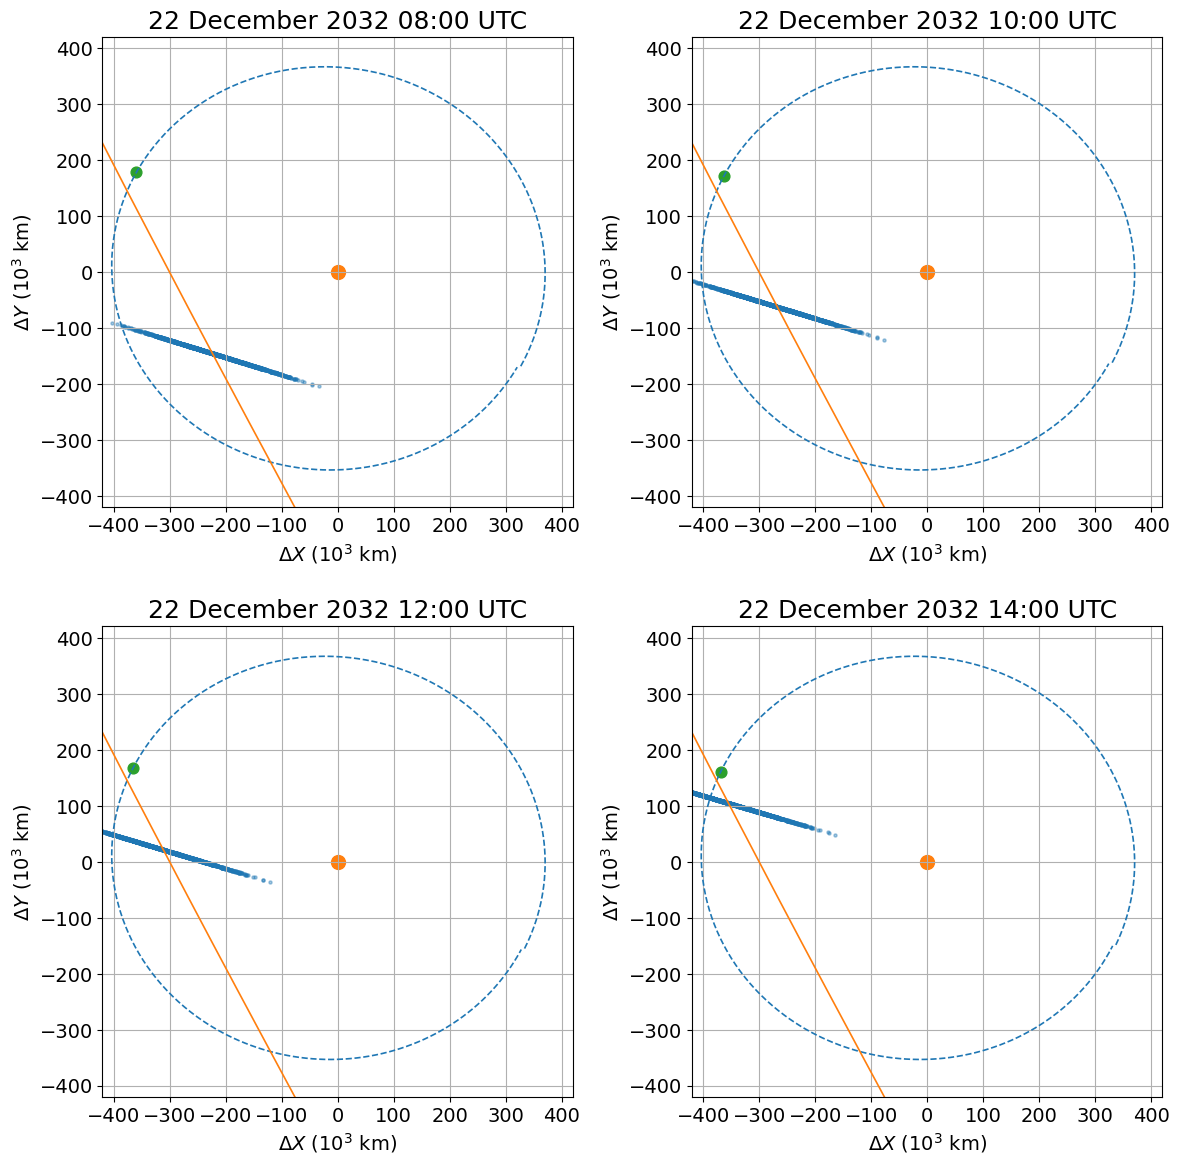

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from datetime import datetime, timedelta

# samakan ukuran font
f_size=14
# samakan ukuran font
plt.rcParams.update({
    "font.size": f_size,
    "axes.titlesize": f_size+4,
    "axes.labelsize": f_size,
    "xtick.labelsize": f_size,
    "ytick.labelsize": f_size,
    "legend.fontsize": f_size
})
# =========================
# PILIH TIMESTEP (dalam jam sejak t0)
# =========================
t_list = [69440, 69442, 69444, 69446]
clone_index = 0

# =========================
# WAKTU AWAL
# =========================
t0 = datetime(2025, 1, 20, 0, 0)

# =========================
# RANGE FIX
# =========================
fixed_min = -420
fixed_max =  420
tick_interval = 100

# =========================
# BUAT FIGURE 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, t_idx in zip(axes, t_list):

    clone_pos = data[t_idx]
    earth = earth_pos[t_idx]
    moon = moon_pos[t_idx]

    # relatif terhadap Earth
    rel_clone = clone_pos - earth
    rel_moon = moon - earth

    x = rel_clone[:, 0]
    y = rel_clone[:, 1]

    moon_x = rel_moon[0]
    moon_y = rel_moon[1]

    # =========================
    # KONVERSI WAKTU
    # =========================
    current_time = t0 + timedelta(hours=int(t_idx))
    time_str = current_time.strftime("%d %B %Y %H:%M UTC")

    # scatter klon
    ax.scatter(x, y, s=5, alpha=0.4)

    # Earth
    ax.scatter(0, 0, s=100)

    # Moon
    ax.scatter(moon_x, moon_y, s=60)

    # =========================
    # ORBIT BULAN (±1/2 periode)
    # =========================
    moon_period = int(27.321661 * 24)
    half_period = moon_period // 2

    start = max(0, t_idx - half_period)
    end   = min(len(moon_pos), t_idx + half_period)

    moon_segment = moon_pos[start:end] - earth_pos[start:end]

    ax.plot(
        moon_segment[:, 0],
        moon_segment[:, 1],
        linestyle='--',
        linewidth=1.2
    )

    # Orbit 1 klon
    clone_orbit_rel = data[:, clone_index, :] - earth_pos

    ax.plot(
        clone_orbit_rel[:, 0],
        clone_orbit_rel[:, 1],
        linewidth=1.2
    )

    # =========================
    # LIMIT FIX
    # =========================
    ax.set_xlim(fixed_min, fixed_max)
    ax.set_ylim(fixed_min, fixed_max)

    ax.xaxis.set_major_locator(MultipleLocator(tick_interval))
    ax.yaxis.set_major_locator(MultipleLocator(tick_interval))

    # label sumbu
    ax.set_xlabel(r"$\Delta X$ ($10^{3}$ km)")
    ax.set_ylabel(r"$\Delta Y$ ($10^{3}$ km)")

    ax.set_aspect('equal', adjustable='box')

    # judul waktu
    ax.set_title(time_str)

    ax.grid(True)

plt.tight_layout()

plt.savefig("perubahan_close_approach_1.png", dpi=600, bbox_inches="tight")

plt.show()